# Context Assembler Compare Rankings — Accuracy & FNR Analysis

Compares **7 context assembler ranking strategies** on the same 272-sample benchmark
using model `qwen3-8b-thinking-sc5`.

Ranking approaches:
- `current` — baseline ranking strategy
- `depth_repeats_context` — depth-repeat-aware ranking
- `dummy` — dummy (random) baseline
- `multiplicative_boost` — multiplicative score boosting
- `random_picking` — random picking
- `security_first` — security-centric prioritisation
- `security_score_only` — security score only (no context weighting)

Each approach was run **4-5 times** on the same dataset. Those repeated runs are used in two ways:

1. **Aggregate mode** - confusion matrices are summed across all runs, then metrics are recomputed from the totals.
2. **Self-confidence mode** - for each sample, the fraction of runs that agree with the majority label
   defines a per-sample *confidence score*. At each confidence threshold only the 'certain enough'
   samples are scored; the rest are abstained.

Key questions:
- Which ranking strategy produces the best accuracy / lowest FNR?
- Does applying a self-confidence threshold improve accuracy or FNR for any approach?

In [1]:
import json
import math
from pathlib import Path
from collections import Counter

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
matplotlib.rcParams['figure.dpi'] = 120

In [2]:
# Configuration

PROJECT_ROOT = Path('__file__').resolve().parent.parent
RESULTS_DIR  = (
    PROJECT_ROOT / 'results'
    / 'context_assembler_compare_rankings_experiments'
    / 'online_models_compare_rankings'
)
MODEL_NAME  = 'claude-sonnet-4-6-thinking-batch'
PROMPT_TYPE = 'strict_exploitable_security'

# Short display name for each approach directory
APPROACH_DISPLAY = {
    'context_assembler_compare_current':               'current',
    'context_assembler_compare_depth_repeats_context': 'depth_repeats',
    'context_assembler_compare_dummy':                 'dummy',
    'context_assembler_compare_multiplicative_boost':  'mult_boost',
    'context_assembler_compare_random_picking':        'random_pick',
    # 'context_assembler_compare_security_first':        'security_first',
    # 'context_assembler_compare_security_score_only':   'security_score',
}

# Self-confidence thresholds (fraction of runs agreeing with majority)
CONF_THRESHOLDS = [0.6, 0.8, 1.0]   # e.g. 3/5, 4/5, 5/5 for 5-run experiments

APPROACH_COLORS = [
    '#4e79a7', '#f28e2b', '#e15759', '#59a14f',
    '#b07aa1', '#ff9da7', '#9c755f',
]

In [3]:
# Helpers

def recompute_metrics(tp, tn, fp, fn):
    """All classification metrics from raw confusion matrix counts."""
    n    = tp + tn + fp + fn
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    denom = math.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc   = (tp * tn - fp * fn) / denom if denom else 0.0
    return dict(
        accuracy=(tp + tn) / n if n else 0.0,
        precision=prec, recall=rec, f1=f1,
        specificity=spec, FNR=1 - rec, FPR=1 - spec, MCC=mcc,
        TP=tp, TN=tn, FP=fp, FN=fn,
    )


def load_reports(approach_dir):
    """Return list of parsed benchmark_report JSON dicts (all runs)."""
    run_dir = approach_dir / MODEL_NAME / PROMPT_TYPE
    reports = []
    for path in sorted(run_dir.glob('benchmark_report_*.json')):
        with open(path) as f:
            reports.append(json.load(f))
    return reports


def aggregate_metrics(reports):
    """Sum confusion matrices across all runs and recompute metrics."""
    tp = tn = fp = fn = 0
    for r in reports:
        cm = r['metrics']['details']['confusion_matrix']
        tp += cm['true_positives']
        tn += cm['true_negatives']
        fp += cm['false_positives']
        fn += cm['false_negatives']
    return {**recompute_metrics(tp, tn, fp, fn), 'n_runs': len(reports)}


def build_per_sample_table(reports):
    """
    Build a per-sample table by aggregating vote_counts from inference_data
    across all runs. Each report's predictions carry vote_counts from
    self-consistency draws (self_consistency_samples per run).
    Returns a DataFrame indexed by sample_id with columns:
      true_label, majority_pred, confidence
    where confidence = max_votes / total_votes (across all runs x draws).
    """
    sample_rows = {}
    for report in reports:
        for pred in report['predictions']:
            if not pred.get('is_success', True):
                continue
            sid = pred['sample_id']
            if sid not in sample_rows:
                sample_rows[sid] = {
                    'true_label':  int(pred['true_label']),
                    'vote_counts': Counter(),
                }
            for label_str, count in pred['inference_data']['vote_counts'].items():
                sample_rows[sid]['vote_counts'][int(label_str)] += count

    rows = {}
    for sid, data in sample_rows.items():
        counts      = data['vote_counts']
        total_votes = sum(counts.values())
        maj_label   = max(counts, key=counts.get)
        maj_votes   = counts[maj_label]
        rows[sid] = {
            'true_label':    data['true_label'],
            'majority_pred': maj_label,
            'confidence':    maj_votes / total_votes if total_votes else 0.0,
        }

    df = pd.DataFrame.from_dict(rows, orient='index')
    df.index.name = 'sample_id'
    return df


def metrics_at_threshold(sample_df, threshold):
    """
    Compute metrics only on samples whose self-confidence >= threshold.
    Returns dict with metrics + coverage (fraction of samples retained).
    """
    sub = sample_df[sample_df['confidence'] >= threshold - 1e-9]
    coverage = len(sub) / len(sample_df)
    tp = int(((sub['majority_pred'] == 1) & (sub['true_label'] == 1)).sum())
    tn = int(((sub['majority_pred'] == 0) & (sub['true_label'] == 0)).sum())
    fp = int(((sub['majority_pred'] == 1) & (sub['true_label'] == 0)).sum())
    fn = int(((sub['majority_pred'] == 0) & (sub['true_label'] == 1)).sum())
    return {**recompute_metrics(tp, tn, fp, fn), 'coverage': coverage, 'n_samples': len(sub)}

In [4]:
# Load data

approach_dirs = [
    d for d in sorted(RESULTS_DIR.iterdir())
    if d.is_dir() and d.name in APPROACH_DISPLAY
]

# Dict: approach_dir_name -> {reports, sample_df}
data = {}
for d in approach_dirs:
    reports = load_reports(d)
    if not reports:
        continue
    sample_df = build_per_sample_table(reports)
    data[d.name] = {'reports': reports, 'sample_df': sample_df}

for name, v in data.items():
    print(
        f"{APPROACH_DISPLAY[name]:>20}  "
        f"{len(v['reports'])} runs  "
        f"{len(v['sample_df'])} samples"
    )

             current  1 runs  100 samples
       depth_repeats  1 runs  100 samples
               dummy  1 runs  100 samples
          mult_boost  1 runs  100 samples
         random_pick  1 runs  100 samples


In [5]:
# Build summary DataFrames

# 1. Aggregated (sum confusion matrices across all runs)
agg_rows = []
for name, v in data.items():
    m = aggregate_metrics(v['reports'])
    agg_rows.append({'approach': APPROACH_DISPLAY[name], **m})
agg_df = pd.DataFrame(agg_rows).sort_values('accuracy', ascending=False).reset_index(drop=True)

# 2. Self-confidence filtered at each threshold
all_thresholds = [0.0] + CONF_THRESHOLDS   # 0.0 = all samples = majority-vote baseline

full_conf_rows = []
for name, v in data.items():
    for thr in all_thresholds:
        m = metrics_at_threshold(v['sample_df'], thr)
        full_conf_rows.append({'approach': APPROACH_DISPLAY[name], 'threshold': thr, **m})
full_conf_df = pd.DataFrame(full_conf_rows)

approaches_by_agg_acc = agg_df['approach'].tolist()

print('Aggregated metrics (all runs summed, no confidence filter):')
display(
    agg_df[['approach', 'n_runs', 'TP', 'TN', 'FP', 'FN',
            'accuracy', 'FNR', 'FPR', 'f1', 'MCC']]
    .round(4)
    .style
    .background_gradient(subset=['accuracy', 'f1', 'MCC'], cmap='RdYlGn', axis=0)
    .background_gradient(subset=['FNR', 'FPR'], cmap='RdYlGn_r', axis=0)
    .format('{:.4f}', subset=['accuracy', 'FNR', 'FPR', 'f1', 'MCC'])
)

Aggregated metrics (all runs summed, no confidence filter):


,approach,n_runs,TP,TN,FP,FN,accuracy,FNR,FPR,f1,MCC
0,depth_repeats,1,36,29,16,19,0.6500,0.3455,0.3556,0.6729,0.2977
1,mult_boost,1,31,30,16,23,0.6100,0.4259,0.3478,0.6139,0.2259
2,dummy,1,22,31,28,19,0.5300,0.4634,0.4746,0.4835,0.0610
3,current,1,24,27,25,24,0.5100,0.5000,0.4808,0.4948,0.0192
4,random_pick,1,22,26,22,30,0.4800,0.5769,0.4583,0.4583,-0.0355


## Baseline Comparison (Aggregated Runs, No Confidence Filter)

/tmp/ipykernel_2023320/4172934526.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=30, ha='right')
/tmp/ipykernel_2023320/4172934526.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=30, ha='right')


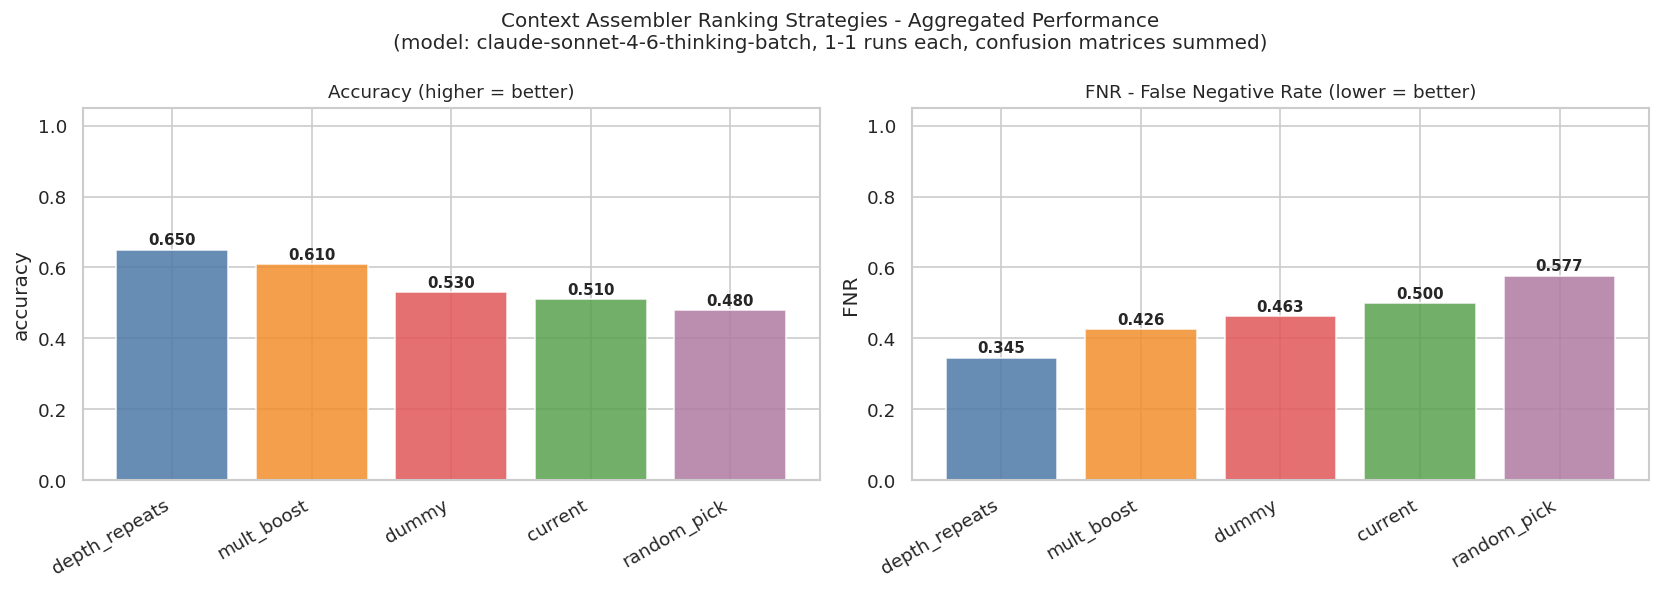

In [6]:
# Bar chart: Accuracy & FNR by approach

colors = APPROACH_COLORS[:len(agg_df)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, title) in zip(axes, [
    ('accuracy', 'Accuracy (higher = better)'),
    ('FNR',      'FNR - False Negative Rate (lower = better)'),
]):
    vals  = agg_df[col].values
    names = agg_df['approach'].tolist()
    bars  = ax.bar(names, vals, color=colors, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(col)
    ax.set_xticklabels(names, rotation=30, ha='right')

n_runs_range = f"{agg_df['n_runs'].min()}-{agg_df['n_runs'].max()}"
fig.suptitle(
    f'Context Assembler Ranking Strategies - Aggregated Performance\n'
    f'(model: {MODEL_NAME}, {n_runs_range} runs each, confusion matrices summed)',
    fontsize=12,
)
fig.tight_layout()
plt.show()

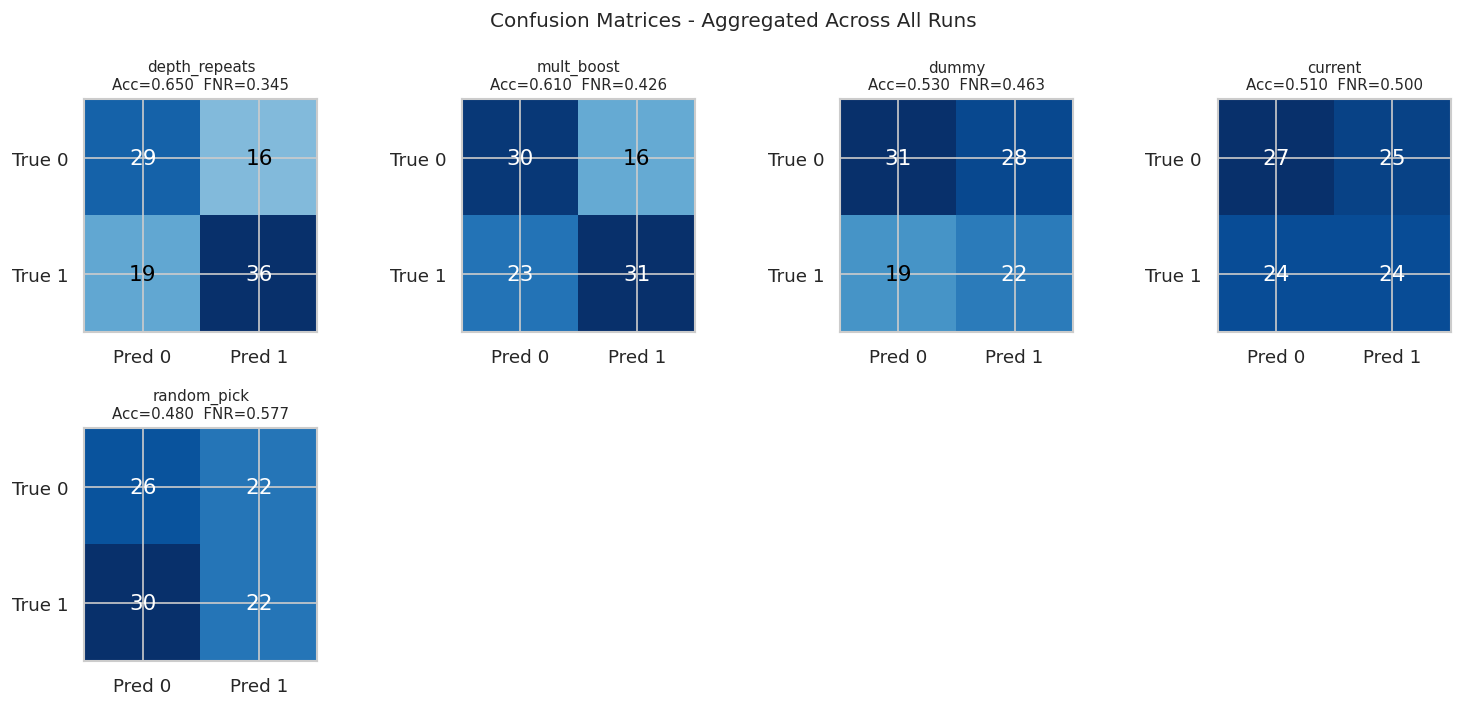

In [7]:
# Confusion matrix heatmap grid

n_ap  = len(agg_df)
ncols = min(4, n_ap)
nrows = math.ceil(n_ap / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.2, nrows * 3.0))
axes = np.array(axes).flatten()

for ax, (_, row) in zip(axes, agg_df.iterrows()):
    cm_arr = np.array([[row['TN'], row['FP']],
                       [row['FN'], row['TP']]])
    ax.imshow(cm_arr, cmap='Blues', vmin=0)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(int(cm_arr[i, j])), ha='center', va='center',
                    fontsize=13,
                    color='black' if cm_arr[i, j] < cm_arr.max() * 0.7 else 'white')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['True 0', 'True 1'])
    ax.set_title(
        f"{row['approach']}\nAcc={row['accuracy']:.3f}  FNR={row['FNR']:.3f}",
        fontsize=9,
    )

for ax in axes[n_ap:]:
    ax.set_visible(False)

fig.suptitle('Confusion Matrices - Aggregated Across All Runs', fontsize=12)
fig.tight_layout()
plt.show()

## Self-Confidence Distribution

For each sample, *confidence* = fraction of runs that agree with the majority-vote predicted label.
A confidence of 1.0 means **all** runs predicted the same label; 0.6 means only 3 out of 5 agreed.
Samples with low confidence are ambiguous - the model keeps 'changing its mind' across runs.

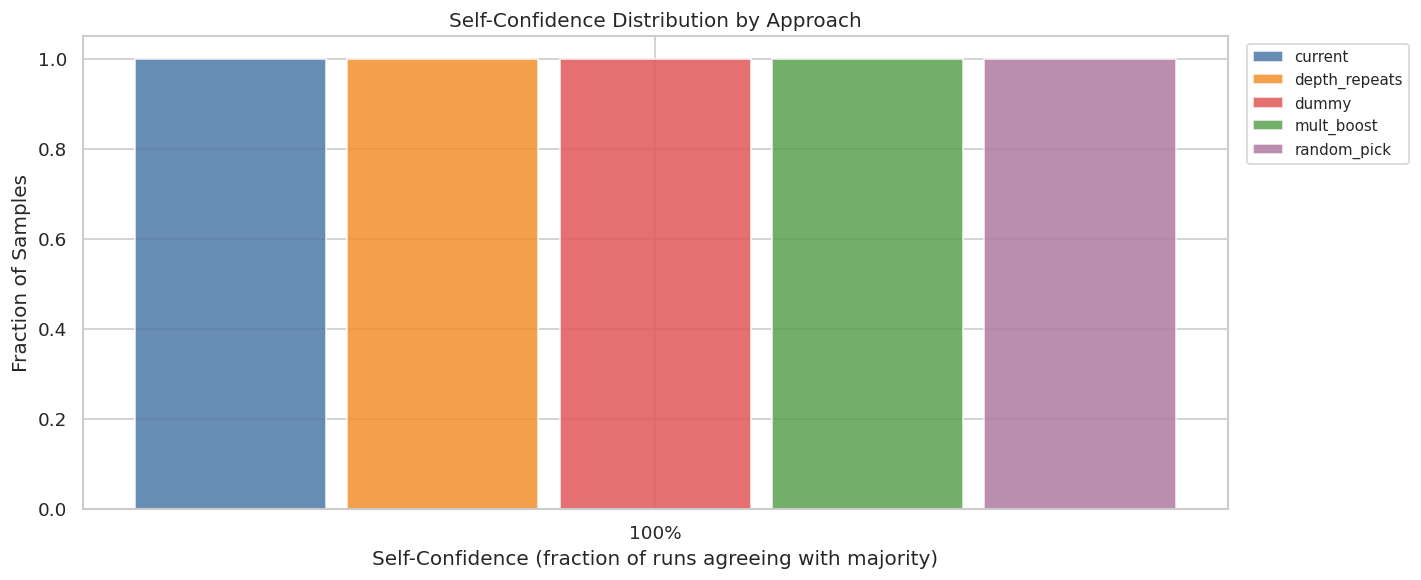

,>=60%,>=80%,>=100%
approach,,,
current,100.0%,100.0%,100.0%
depth_repeats,100.0%,100.0%,100.0%
dummy,100.0%,100.0%,100.0%
mult_boost,100.0%,100.0%,100.0%
random_pick,100.0%,100.0%,100.0%


In [8]:
# Confidence distribution per approach

conf_levels = sorted(
    set(v for vv in data.values() for v in vv['sample_df']['confidence'].unique())
)

x     = np.arange(len(conf_levels))
bar_w = 0.8 / len(data)

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, v) in enumerate(data.items()):
    counts = (
        v['sample_df']['confidence']
        .value_counts(normalize=True)
        .reindex(conf_levels, fill_value=0)
    )
    ax.bar(x + i * bar_w, counts.values, bar_w * 0.9,
           label=APPROACH_DISPLAY[name], color=APPROACH_COLORS[i], alpha=0.85)

ax.set_xticks(x + bar_w * (len(data) - 1) / 2)
ax.set_xticklabels([f'{c:.0%}' for c in conf_levels])
ax.set_xlabel('Self-Confidence (fraction of runs agreeing with majority)')
ax.set_ylabel('Fraction of Samples')
ax.set_title('Self-Confidence Distribution by Approach')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
fig.tight_layout()
plt.show()

# Coverage at each threshold
cov_rows = []
for name, v in data.items():
    sdf = v['sample_df']
    row = {'approach': APPROACH_DISPLAY[name]}
    for thr in CONF_THRESHOLDS:
        row[f'>={thr:.0%}'] = (sdf['confidence'] >= thr - 1e-9).sum() / len(sdf)
    cov_rows.append(row)

display(
    pd.DataFrame(cov_rows).set_index('approach')
    .round(3)
    .style
    .background_gradient(cmap='Blues', axis=None)
    .format('{:.1%}')
    .set_caption('Coverage (fraction of samples retained) at Each Self-Confidence Threshold')
)

## Self-Confidence Filtered Metrics

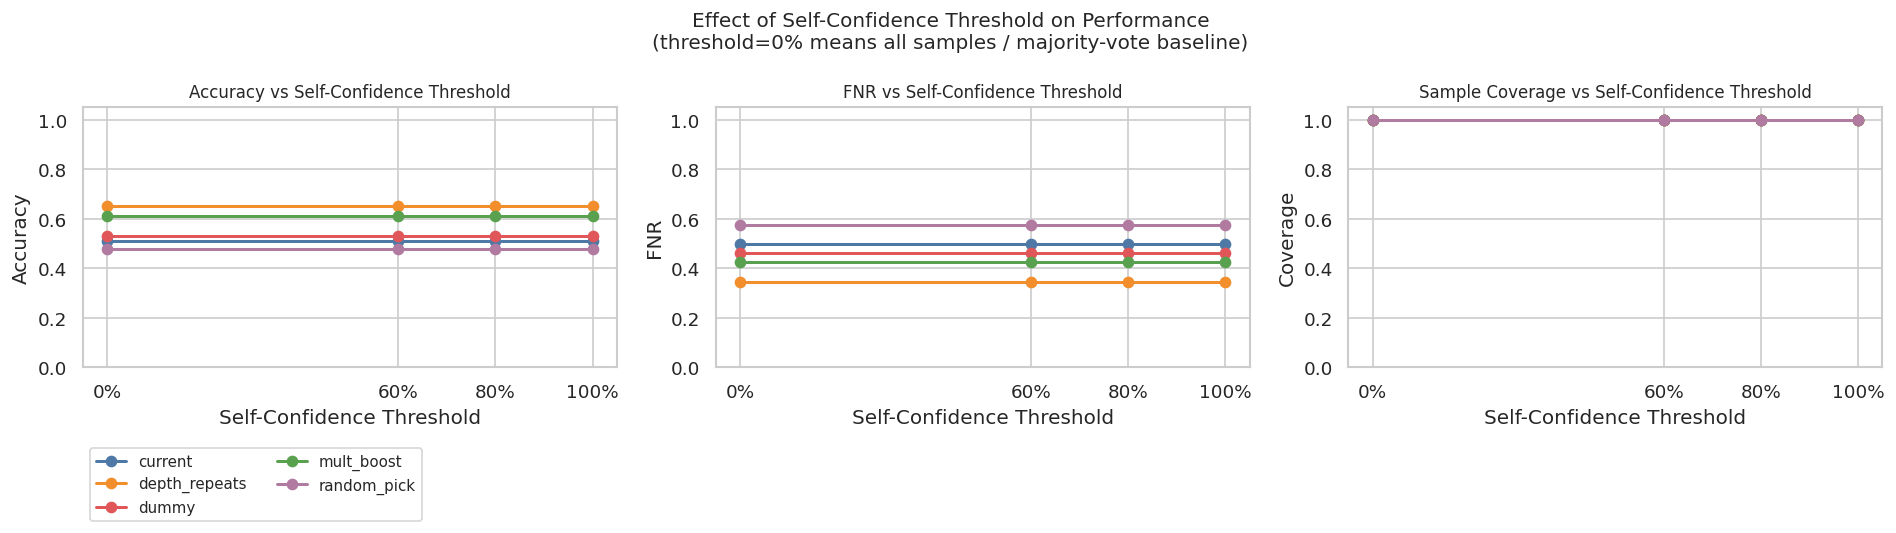

In [9]:
# Line plots: accuracy, FNR & coverage vs confidence threshold

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, (col, ylabel, title) in zip(axes, [
    ('accuracy', 'Accuracy',  'Accuracy vs Self-Confidence Threshold'),
    ('FNR',      'FNR',       'FNR vs Self-Confidence Threshold'),
    ('coverage', 'Coverage',  'Sample Coverage vs Self-Confidence Threshold'),
]):
    for i, (name, _) in enumerate(data.items()):
        label = APPROACH_DISPLAY[name]
        sub   = full_conf_df[full_conf_df['approach'] == label].sort_values('threshold')
        ax.plot(sub['threshold'], sub[col], marker='o', label=label,
                color=APPROACH_COLORS[i], linewidth=1.8)
    ax.set_xlabel('Self-Confidence Threshold')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(all_thresholds)
    ax.set_xticklabels([f'{t:.0%}' for t in all_thresholds])
    ax.set_ylim(0, 1.05)

axes[0].legend(bbox_to_anchor=(0, -0.28), loc='upper left', ncol=2, fontsize=9)
fig.suptitle(
    'Effect of Self-Confidence Threshold on Performance\n'
    '(threshold=0% means all samples / majority-vote baseline)',
    fontsize=12,
)
fig.tight_layout()
plt.show()

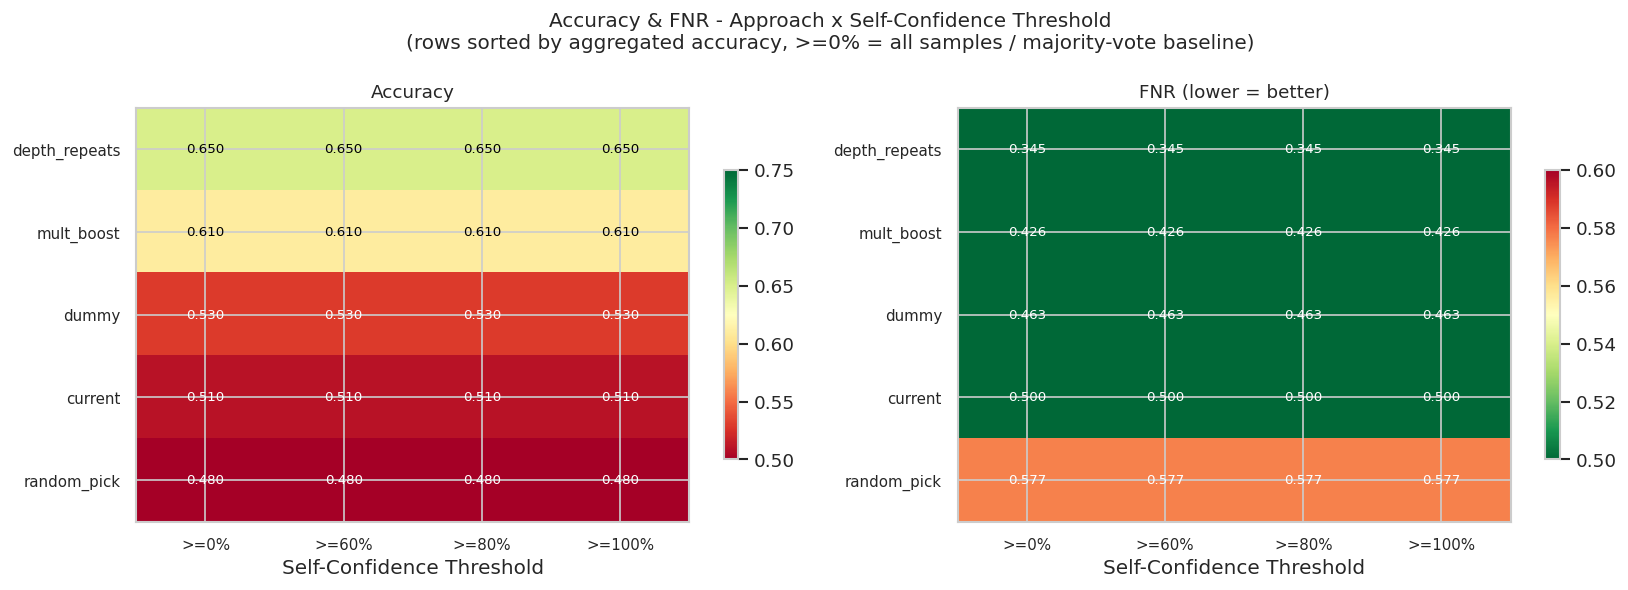

In [10]:
# Heatmaps: accuracy and FNR per (approach, threshold)

thresholds_str = [f'>={t:.0%}' for t in all_thresholds]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, cmap, vmin, vmax, title) in zip(axes, [
    ('accuracy', 'RdYlGn',   0.5, 0.75, 'Accuracy'),
    ('FNR',      'RdYlGn_r', 0.50, 0.60, 'FNR (lower = better)'),
]):
    pivot = (
        full_conf_df
        .assign(thr_label=lambda df: df['threshold'].map(lambda t: f'>={t:.0%}'))
        .pivot_table(index='approach', columns='thr_label', values=col, aggfunc='first')
        .reindex(index=approaches_by_agg_acc, columns=thresholds_str)
    )
    im = ax.imshow(pivot.values.astype(float), cmap=cmap,
                   vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(thresholds_str)))
    ax.set_xticklabels(thresholds_str, fontsize=9)
    ax.set_yticks(range(len(approaches_by_agg_acc)))
    ax.set_yticklabels(approaches_by_agg_acc, fontsize=9)
    ax.set_xlabel('Self-Confidence Threshold')
    ax.set_title(title, fontsize=11)
    for i, ap in enumerate(approaches_by_agg_acc):
        for j, tl in enumerate(thresholds_str):
            v = pivot.loc[ap, tl]
            if not np.isnan(v):
                mid_lo = vmin + 0.25 * (vmax - vmin)
                mid_hi = vmin + 0.75 * (vmax - vmin)
                tc = 'black' if mid_lo < v < mid_hi else 'white'
                ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=8, color=tc)
    plt.colorbar(im, ax=ax, shrink=0.7)

fig.suptitle(
    'Accuracy & FNR - Approach x Self-Confidence Threshold\n'
    '(rows sorted by aggregated accuracy, >=0% = all samples / majority-vote baseline)',
    fontsize=12,
)
fig.tight_layout()
plt.show()

In [11]:
# Detailed metrics table at each threshold

for thr in all_thresholds:
    sub = (
        full_conf_df[full_conf_df['threshold'] == thr]
        .set_index('approach')
        .reindex(approaches_by_agg_acc)
        [['n_samples', 'coverage', 'TP', 'TN', 'FP', 'FN',
          'accuracy', 'FNR', 'FPR', 'precision', 'recall', 'f1', 'MCC']]
    )
    print(f'\n--- Self-Confidence Threshold >= {thr:.0%} ---')
    display(
        sub.round(4)
        .style
        .background_gradient(subset=['accuracy', 'f1', 'MCC'], cmap='RdYlGn', axis=0)
        .background_gradient(subset=['FNR', 'FPR'], cmap='RdYlGn_r', axis=0)
        .background_gradient(subset=['coverage'], cmap='Blues', axis=0)
        .format('{:.4f}', subset=['coverage', 'accuracy', 'FNR', 'FPR',
                                   'precision', 'recall', 'f1', 'MCC'])
        .format('{:.0f}', subset=['n_samples', 'TP', 'TN', 'FP', 'FN'])
    )


--- Self-Confidence Threshold >= 0% ---


,n_samples,coverage,TP,TN,FP,FN,accuracy,FNR,FPR,precision,recall,f1,MCC
approach,,,,,,,,,,,,,
depth_repeats,100,1.0000,36,29,16,19,0.6500,0.3455,0.3556,0.6923,0.6545,0.6729,0.2977
mult_boost,100,1.0000,31,30,16,23,0.6100,0.4259,0.3478,0.6596,0.5741,0.6139,0.2259
dummy,100,1.0000,22,31,28,19,0.5300,0.4634,0.4746,0.4400,0.5366,0.4835,0.0610
current,100,1.0000,24,27,25,24,0.5100,0.5000,0.4808,0.4898,0.5000,0.4948,0.0192
random_pick,100,1.0000,22,26,22,30,0.4800,0.5769,0.4583,0.5000,0.4231,0.4583,-0.0355



--- Self-Confidence Threshold >= 60% ---


,n_samples,coverage,TP,TN,FP,FN,accuracy,FNR,FPR,precision,recall,f1,MCC
approach,,,,,,,,,,,,,
depth_repeats,100,1.0000,36,29,16,19,0.6500,0.3455,0.3556,0.6923,0.6545,0.6729,0.2977
mult_boost,100,1.0000,31,30,16,23,0.6100,0.4259,0.3478,0.6596,0.5741,0.6139,0.2259
dummy,100,1.0000,22,31,28,19,0.5300,0.4634,0.4746,0.4400,0.5366,0.4835,0.0610
current,100,1.0000,24,27,25,24,0.5100,0.5000,0.4808,0.4898,0.5000,0.4948,0.0192
random_pick,100,1.0000,22,26,22,30,0.4800,0.5769,0.4583,0.5000,0.4231,0.4583,-0.0355



--- Self-Confidence Threshold >= 80% ---


,n_samples,coverage,TP,TN,FP,FN,accuracy,FNR,FPR,precision,recall,f1,MCC
approach,,,,,,,,,,,,,
depth_repeats,100,1.0000,36,29,16,19,0.6500,0.3455,0.3556,0.6923,0.6545,0.6729,0.2977
mult_boost,100,1.0000,31,30,16,23,0.6100,0.4259,0.3478,0.6596,0.5741,0.6139,0.2259
dummy,100,1.0000,22,31,28,19,0.5300,0.4634,0.4746,0.4400,0.5366,0.4835,0.0610
current,100,1.0000,24,27,25,24,0.5100,0.5000,0.4808,0.4898,0.5000,0.4948,0.0192
random_pick,100,1.0000,22,26,22,30,0.4800,0.5769,0.4583,0.5000,0.4231,0.4583,-0.0355



--- Self-Confidence Threshold >= 100% ---


,n_samples,coverage,TP,TN,FP,FN,accuracy,FNR,FPR,precision,recall,f1,MCC
approach,,,,,,,,,,,,,
depth_repeats,100,1.0000,36,29,16,19,0.6500,0.3455,0.3556,0.6923,0.6545,0.6729,0.2977
mult_boost,100,1.0000,31,30,16,23,0.6100,0.4259,0.3478,0.6596,0.5741,0.6139,0.2259
dummy,100,1.0000,22,31,28,19,0.5300,0.4634,0.4746,0.4400,0.5366,0.4835,0.0610
current,100,1.0000,24,27,25,24,0.5100,0.5000,0.4808,0.4898,0.5000,0.4948,0.0192
random_pick,100,1.0000,22,26,22,30,0.4800,0.5769,0.4583,0.5000,0.4231,0.4583,-0.0355


## Self-Confidence Calibration

Does higher self-confidence correlate with being correct?
A well-calibrated confidence signal should show higher accuracy at higher confidence levels.

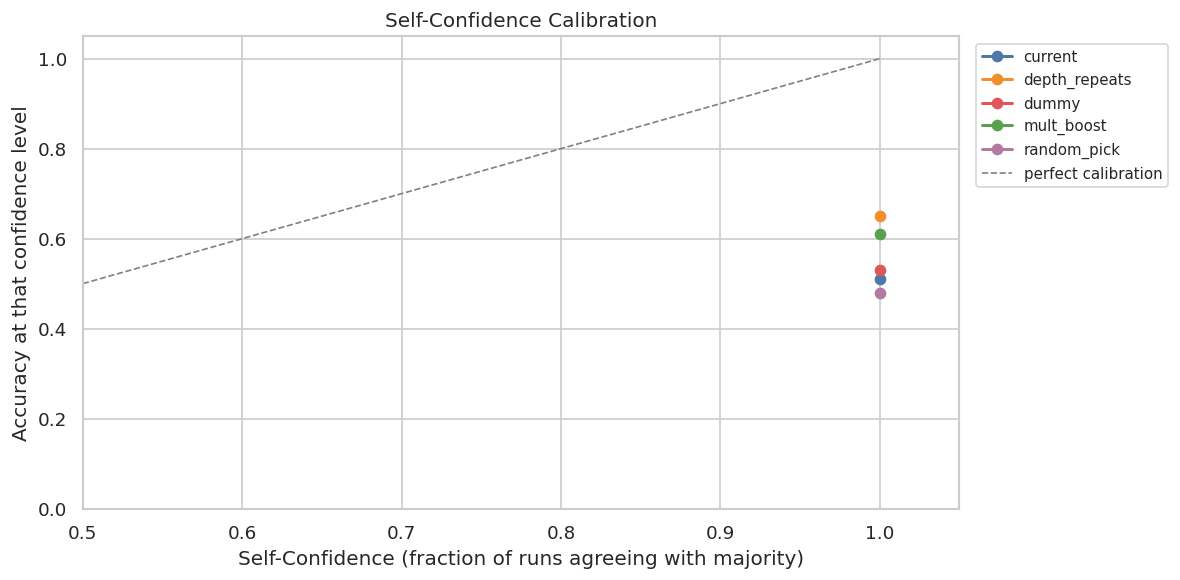

confidence,1.000000
approach,
depth_repeats,0.650
mult_boost,0.610
dummy,0.530
current,0.510
random_pick,0.480


In [12]:
# Accuracy at each confidence level (calibration)

cal_rows = []
for name, v in data.items():
    sdf = v['sample_df'].copy()
    sdf['correct'] = (sdf['majority_pred'] == sdf['true_label']).astype(int)
    for conf, grp in sdf.groupby('confidence'):
        cal_rows.append({
            'approach':  APPROACH_DISPLAY[name],
            'confidence': conf,
            'accuracy':  grp['correct'].mean(),
            'n':         len(grp),
        })
cal_df = pd.DataFrame(cal_rows)

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, _) in enumerate(data.items()):
    label = APPROACH_DISPLAY[name]
    sub = cal_df[cal_df['approach'] == label].sort_values('confidence')
    ax.plot(sub['confidence'], sub['accuracy'], marker='o', label=label,
            color=APPROACH_COLORS[i], linewidth=1.8)

ax.plot([0.5, 1.0], [0.5, 1.0], color='gray', linestyle='--',
        linewidth=1, label='perfect calibration')
ax.set_xlabel('Self-Confidence (fraction of runs agreeing with majority)')
ax.set_ylabel('Accuracy at that confidence level')
ax.set_title('Self-Confidence Calibration')
ax.set_xlim(0.5, 1.05)
ax.set_ylim(0.0, 1.05)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
fig.tight_layout()
plt.show()

display(
    cal_df.pivot_table(index='approach', columns='confidence',
                       values='accuracy', aggfunc='first')
    .reindex(index=approaches_by_agg_acc)
    .round(3)
    .style
    .background_gradient(cmap='RdYlGn', vmin=0.4, vmax=0.9, axis=None)
    .format('{:.3f}')
    .set_caption('Accuracy at Each Confidence Level (NaN = no samples at that confidence)')
)

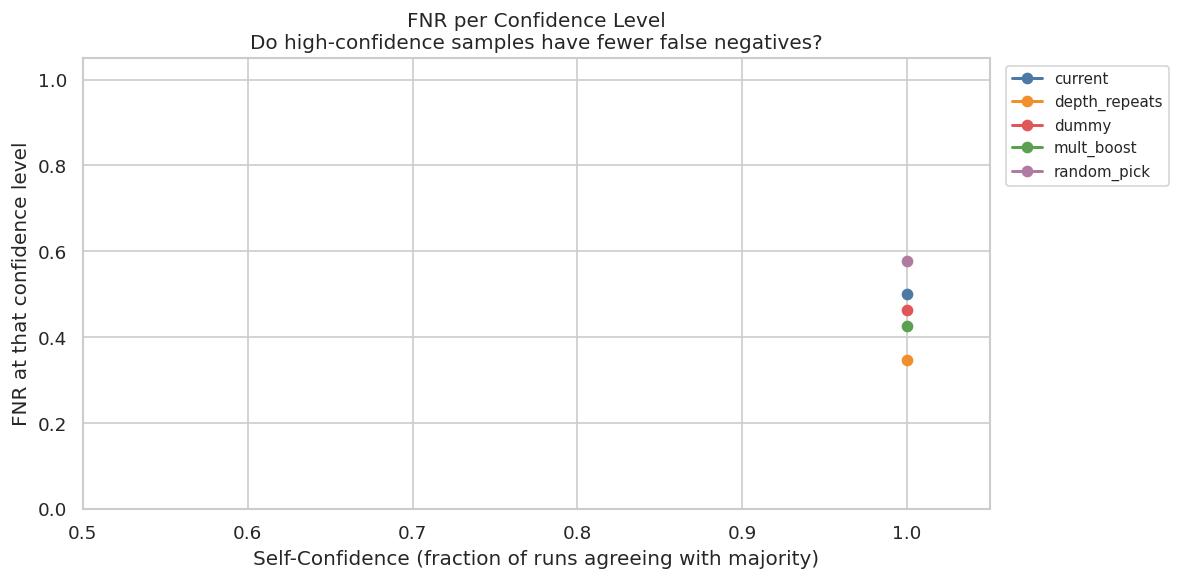

In [13]:
# FNR at each confidence level

fnr_rows = []
for name, v in data.items():
    sdf = v['sample_df']
    for conf, grp in sdf.groupby('confidence'):
        pos = grp[grp['true_label'] == 1]
        fn  = int((pos['majority_pred'] == 0).sum())
        fnr = fn / len(pos) if len(pos) else float('nan')
        fnr_rows.append({'approach': APPROACH_DISPLAY[name], 'confidence': conf, 'FNR': fnr})
fnr_cal_df = pd.DataFrame(fnr_rows)

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, _) in enumerate(data.items()):
    label = APPROACH_DISPLAY[name]
    sub = fnr_cal_df[fnr_cal_df['approach'] == label].sort_values('confidence')
    ax.plot(sub['confidence'], sub['FNR'], marker='o', label=label,
            color=APPROACH_COLORS[i], linewidth=1.8)
ax.set_xlabel('Self-Confidence (fraction of runs agreeing with majority)')
ax.set_ylabel('FNR at that confidence level')
ax.set_title('FNR per Confidence Level\nDo high-confidence samples have fewer false negatives?')
ax.set_xlim(0.5, 1.05)
ax.set_ylim(0.0, 1.05)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
fig.tight_layout()
plt.show()

## Summary

In [14]:
# Best approach at each threshold

print('Best approach by ACCURACY at each self-confidence threshold:')
for thr in all_thresholds:
    sub  = full_conf_df[full_conf_df['threshold'] == thr]
    best = sub.loc[sub['accuracy'].idxmax()]
    print(
        f"  >={thr:.0%}  ->  {best['approach']:>14}  "
        f"acc={best['accuracy']:.4f}  "
        f"FNR={best['FNR']:.4f}  "
        f"coverage={best['coverage']:.1%}"
    )

print()
print('Best approach by FNR (lowest) at each self-confidence threshold:')
for thr in all_thresholds:
    sub  = full_conf_df[full_conf_df['threshold'] == thr]
    best = sub.loc[sub['FNR'].idxmin()]
    print(
        f"  >={thr:.0%}  ->  {best['approach']:>14}  "
        f"FNR={best['FNR']:.4f}  "
        f"acc={best['accuracy']:.4f}  "
        f"coverage={best['coverage']:.1%}"
    )

Best approach by ACCURACY at each self-confidence threshold:
  >=0%  ->   depth_repeats  acc=0.6500  FNR=0.3455  coverage=100.0%
  >=60%  ->   depth_repeats  acc=0.6500  FNR=0.3455  coverage=100.0%
  >=80%  ->   depth_repeats  acc=0.6500  FNR=0.3455  coverage=100.0%
  >=100%  ->   depth_repeats  acc=0.6500  FNR=0.3455  coverage=100.0%

Best approach by FNR (lowest) at each self-confidence threshold:
  >=0%  ->   depth_repeats  FNR=0.3455  acc=0.6500  coverage=100.0%
  >=60%  ->   depth_repeats  FNR=0.3455  acc=0.6500  coverage=100.0%
  >=80%  ->   depth_repeats  FNR=0.3455  acc=0.6500  coverage=100.0%
  >=100%  ->   depth_repeats  FNR=0.3455  acc=0.6500  coverage=100.0%


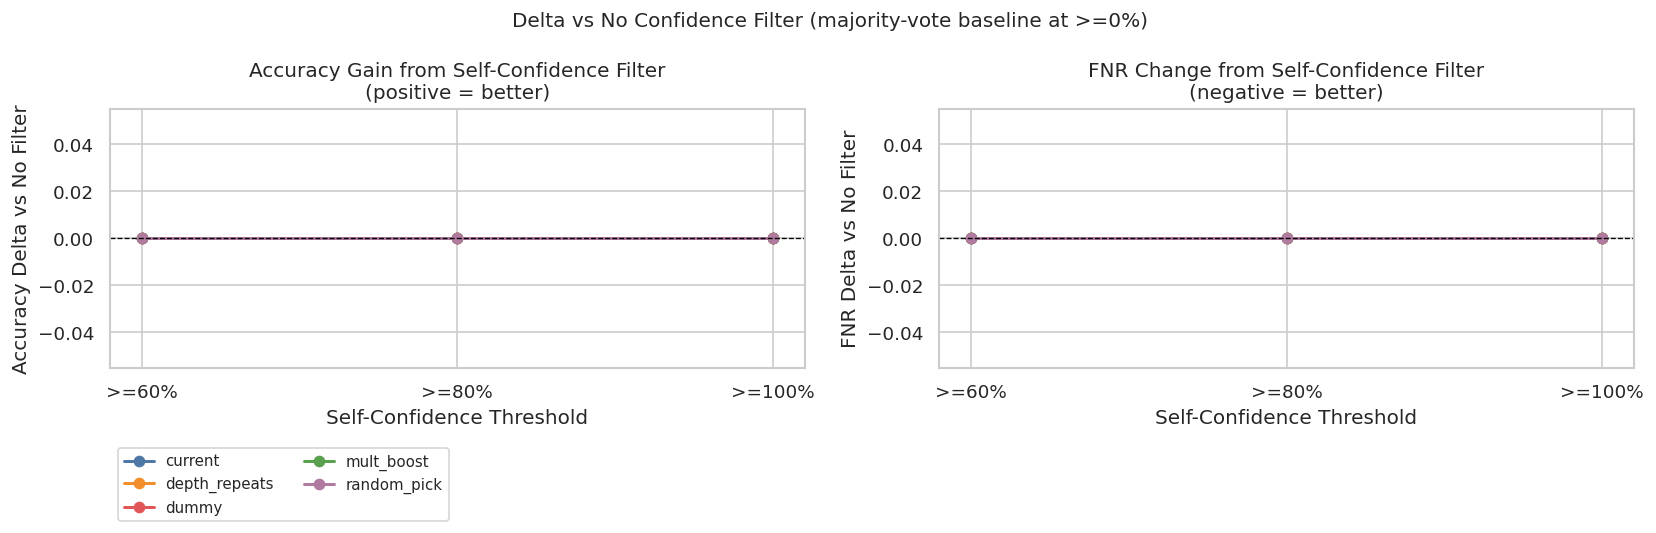

In [15]:
# Delta: metric(threshold) - metric(no filter) per approach

base = (
    full_conf_df[full_conf_df['threshold'] == 0.0]
    [['approach', 'accuracy', 'FNR']]
    .rename(columns={'accuracy': 'acc_base', 'FNR': 'fnr_base'})
)
delta_df = full_conf_df[full_conf_df['threshold'] > 0].merge(base, on='approach')
delta_df['delta_acc'] = delta_df['accuracy'] - delta_df['acc_base']
delta_df['delta_fnr'] = delta_df['FNR']      - delta_df['fnr_base']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
thr_labels = [f'>={t:.0%}' for t in CONF_THRESHOLDS]

for ax, (col, ylabel, title, note) in zip(axes, [
    ('delta_acc', 'Accuracy Delta vs No Filter',
     'Accuracy Gain from Self-Confidence Filter', '(positive = better)'),
    ('delta_fnr', 'FNR Delta vs No Filter',
     'FNR Change from Self-Confidence Filter',    '(negative = better)'),
]):
    for i, (name, _) in enumerate(data.items()):
        label = APPROACH_DISPLAY[name]
        sub   = (
            delta_df[delta_df['approach'] == label]
            .sort_values('threshold')
            .assign(thr_label=lambda d: d['threshold'].map(lambda t: f'>={t:.0%}'))
        )
        ax.plot(sub['thr_label'], sub[col], marker='o', label=label,
                color=APPROACH_COLORS[i], linewidth=1.8)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Self-Confidence Threshold')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title}\n{note}')

axes[0].legend(bbox_to_anchor=(0, -0.28), loc='upper left', ncol=2, fontsize=9)
fig.suptitle(
    'Delta vs No Confidence Filter (majority-vote baseline at >=0%)',
    fontsize=12,
)
fig.tight_layout()
plt.show()